In [1]:
import os
import sys

#import tensorflow as tf
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sys.path.append(os.pardir)
from rsmine.mi_estimator.mi_estimator import VBMI

In [3]:
def sample_correlated_gaussian(rho=0.5, dim=20, n=1, batch_size=128):
    """Generate samples from a correlated Gaussian distribution."""
    samples = torch.randn(batch_size, 2 * dim, n)
    x, eps = torch.split(samples, dim, dim=1)
    scale = torch.sqrt(torch.tensor(1.0 - rho**2, dtype=torch.float32))
    y = rho * x + scale * eps
    return x, y


def rho_to_mi(dim, rho):
  return -0.5 * np.log(1-rho**2) * dim


def mi_to_rho(dim, mi):
  return np.sqrt(1-np.exp(-2.0 / dim * mi))

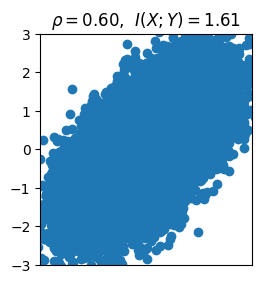

In [11]:
N_samples = 20000
batch_size = 500 # 256
L_E = 5
n = 1

plt.figure(figsize=(6, 3))
for i, rho in enumerate([0.6]):
  plt.subplot(1, 2, i + 1)
  x, y = sample_correlated_gaussian(
      batch_size=N_samples, dim=L_E, n=n, rho=rho)
  exact_mi = n * rho_to_mi(L_E, rho)

  plt.scatter(x[:, 0], y[:, 0])
  plt.title(r'$\rho=%.2f$,  $I(X; Y)=%.2f$' % (rho, exact_mi / np.log(2)))
  plt.xlim(-3, 3)
  plt.ylim(-3, 3)
  plt.xticks([])

In [12]:
input_shapes = [(L_E, n), (L_E, n)]

vbmi = VBMI(
    batch_size,
    bound='dv',
    input_shapes=input_shapes,
    layers=2,
    embed_dim=32,
    hidden_dim=64,
    activation=torch.nn.ReLU,
    shuffle=True,
    learning_rate=1e-4,
    iterations=150,
    use_dropout=True,
    dropout_rate=0.2,
)

In [13]:
mis = vbmi.MI(x, y)
mis = np.array(mis) / np.log(2)  # convert to bits

  0%|          | 0/6000 [00:00<?, ?it/s]

Text(0, 0.5, '$I(X:Y)$ (bits)')

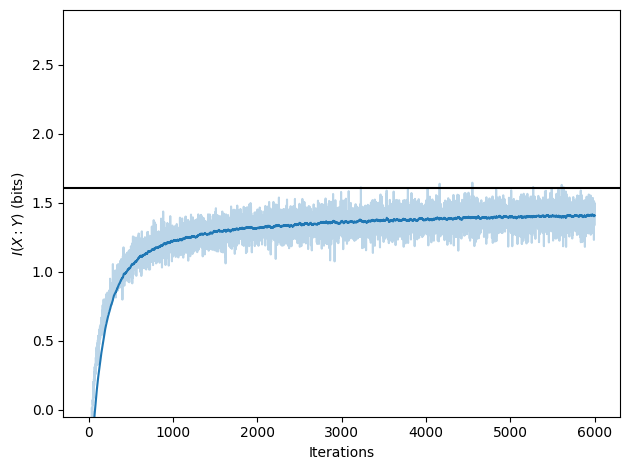

In [14]:
fig, ax = plt.subplots(tight_layout=True)

EMA_SPAN = 100
mis_smooth = pd.Series(mis).ewm(span=EMA_SPAN).mean()
p1 = ax.plot(mis, alpha=0.3)[0]
ax.plot(mis_smooth, c=p1.get_color())
ax.axhline(y=exact_mi / np.log(2), c="k", linestyle="-")
ax.axhline(np.log(batch_size), c="k", linestyle="--", label=r"1 + log(K/$\alpha$)")
ax.set_ylim([-0.05, 1.8 * exact_mi / np.log(2)])
ax.set_xlabel("Iterations")
ax.set_ylabel("$I(X:Y)$ (bits)")